In [1]:
# 
#
#
#
# Cosmic-Ray Rejection for Keck/LRIS Spectra
#
#
#
#

In [3]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.stats import norm
from astropy.visualization import simple_norm
from scipy.ndimage import binary_dilation

In [3]:
# working with extension 2

In [4]:
fits.open("Part_1/b211011_0102.fits.gz").info()

Filename: Part_1/b211011_0102.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     720   ()      
  1  VidInp1       1 ImageHDU       360   (1155, 4096)   int16 (rescales to uint16)   
  2  VidInp2       1 ImageHDU       360   (1155, 4096)   int16 (rescales to uint16)   
  3  VidInp3       1 ImageHDU       360   (1155, 4096)   int16 (rescales to uint16)   
  4  VidInp4       1 ImageHDU       360   (1155, 4096)   int16 (rescales to uint16)   


In [5]:
files = sorted(glob.glob("Part_1/b211011_01*.fits.gz"))

In [6]:
files

['Part_1/b211011_0102.fits.gz',
 'Part_1/b211011_0103.fits.gz',
 'Part_1/b211011_0104.fits.gz',
 'Part_1/b211011_0105.fits.gz',
 'Part_1/b211011_0106.fits.gz',
 'Part_1/b211011_0107.fits.gz',
 'Part_1/b211011_0108.fits.gz',
 'Part_1/b211011_0109.fits.gz']

Checking file:  Part_1/b211011_0102.fits.gz
Checking file:  Part_1/b211011_0103.fits.gz
Checking file:  Part_1/b211011_0104.fits.gz
Checking file:  Part_1/b211011_0105.fits.gz
Checking file:  Part_1/b211011_0106.fits.gz
bias dimension:  (5, 4096, 1155)
median_bias_image dimension =  (4096, 1155)
Displaying master bias image...



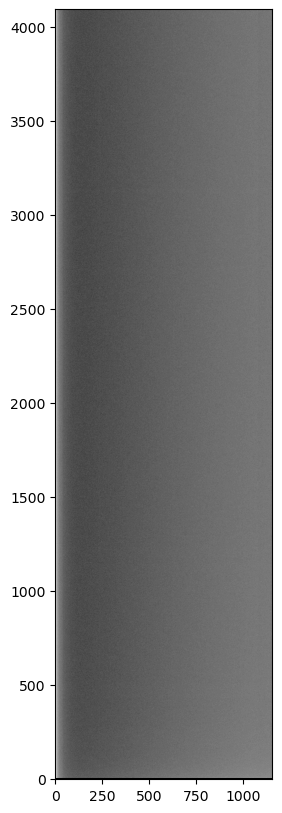

In [7]:
# Creating master bias

files = sorted(glob.glob("Part_1/b211011_01*.fits.gz"))

chip_bias = []
for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure != 0:
        hdul.close()
        continue

    
    data = hdul[2].data

    print(F"Checking file: ", fname)

    chip_bias.append(data)
    hdul.close()
print(F"bias dimension: ", np.shape(chip_bias))

median_bias_image = (np.median(chip_bias, axis = 0))

print(F"median_bias_image dimension = ", np.shape(median_bias_image))
print("Displaying master bias image...")
print("")

norm = simple_norm(median_bias_image, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(median_bias_image, origin = 'lower', cmap = "grey", norm = norm)
plt.show()
#
# Visual of the master bias

In [8]:
# The above shows that the loop worked. Our final master bias has the right dimensions and an image of master bias is provided

In [9]:
minus_bias = []
for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure == 0:
        hdul.close()
        continue
        
    print(F"Checking file: ", fname)
    
    minus_bias.append(hdul[2].data - median_bias_image)
    hdul.close()
print(F"minus_bias dimensions: ", np.shape(minus_bias))

sum_data = (np.sum(minus_bias, axis = 0))

print(F"sum_data dimension: ", np.shape(sum_data))

Checking file:  Part_1/b211011_0107.fits.gz
Checking file:  Part_1/b211011_0108.fits.gz
Checking file:  Part_1/b211011_0109.fits.gz
minus_bias dimensions:  (3, 4096, 1155)
sum_data dimension:  (4096, 1155)


In [10]:
# So far the loop worked. Creating an image with the master bias subtracted

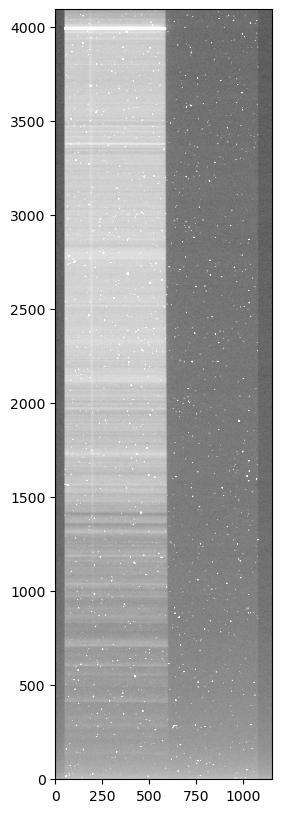

In [11]:
norm = simple_norm(sum_data, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(sum_data, origin = "lower", cmap = "grey", norm = norm)
plt.show()
# its best shown on ds9
# Visual of the result. Shows cosmic rays and bad pixels.

In [12]:
fits.writeto("dsl_sum_data", sum_data, overwrite = True)
# for a better view in ds9

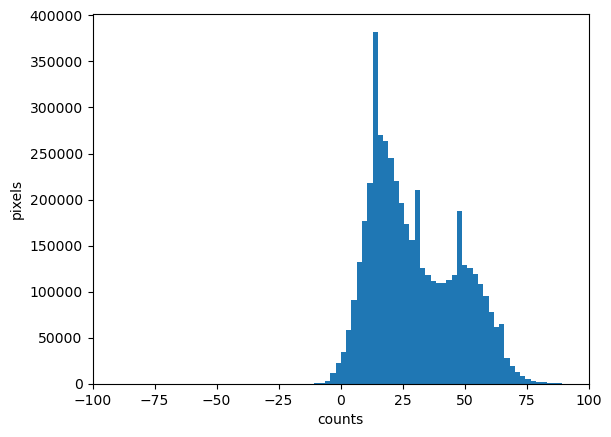

In [13]:
# Providing a plot showing the distribution of counts 
# per pixel in the summed, bias-subtracted science image.
plt.hist(sum_data.flatten(), bins = 10000)
plt.xlim(-100,100)
plt.xlabel("counts")
plt.ylabel("pixels")
plt.show()

In [14]:
fits.writeto("107_ext2", fits.open("Part_1/b211011_0107.fits.gz")[2].data, overwrite = True)
# So I can see the image 107 in ds9

In [15]:
#
#
#
#
#

In [16]:
# Using extension 2, we need to mask out cosmic rays.
# We will use pixels counts within 50 of the median.
# We will assume files 107 - 109 are similar,
# so will work with 107 to create a mask.
#
# Spoiler: Using only file 107 did not work. Wrote a code that gets the mask of each indivually.
# Nevertheless, I started with file 107 so that I may streamline for others

In [17]:
data_107 = fits.open("Part_1/b211011_0107.fits.gz")[2].data

In [18]:
data_107.size

4730880

In [19]:
data_107_median = np.median(data_107)
data_107_median

1000.0

In [20]:
# Getting range within 50

In [21]:
data_107_median_mask = (data_107_median - 50 <= data_107) & (data_107 <= 50 + data_107_median)

In [22]:
data_107_median_range = data_107[data_107_median_mask]

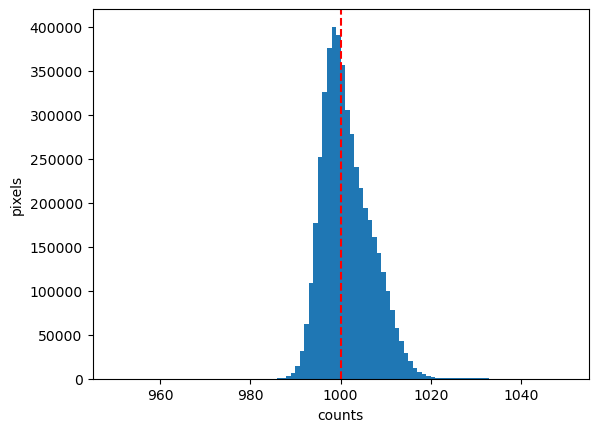

In [23]:
plt.hist(data_107_median_range, bins = 100)
plt.axvline(data_107_median, color = "red", linestyle = "--")
plt.xlabel("counts")
plt.ylabel("pixels")
plt.show()

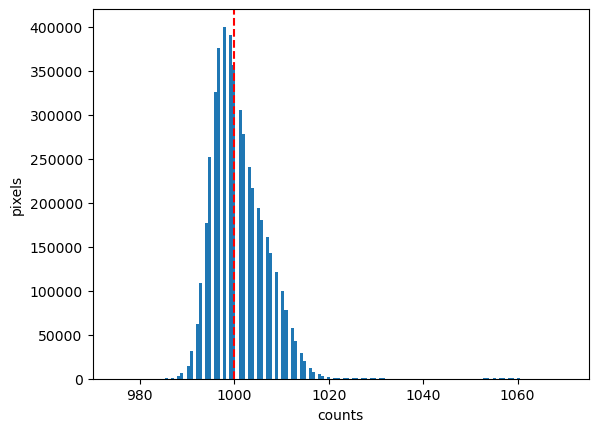

In [24]:
plt.hist(data_107.flatten(), bins = 100000)
plt.axvline(data_107_median, color = "red", linestyle = "--")
plt.xlim(970,1075)
plt.xlabel("counts")
plt.ylabel("pixels")
plt.show()

In [25]:
# So far the the histogram gives us a proper representation within 50.
# Now we can get the standard deviation within this range

In [26]:
data_107_std = np.std(data_107_median_range)
data_107_std

5.462891222375049

In [27]:
# I will choose the same range for the multiplier of the standard deviation 
# and change it in order to cover the cosmic rays if needed

In [28]:
above_10_std = (data_107 >= data_107_median + data_107_std*10)
above_10_std

array([[False,  True, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       ...,
       [False,  True, False, ..., False, False, False],
       [False,  True,  True, ..., False, False, False],
       [False,  True, False, ..., False, False, False]])

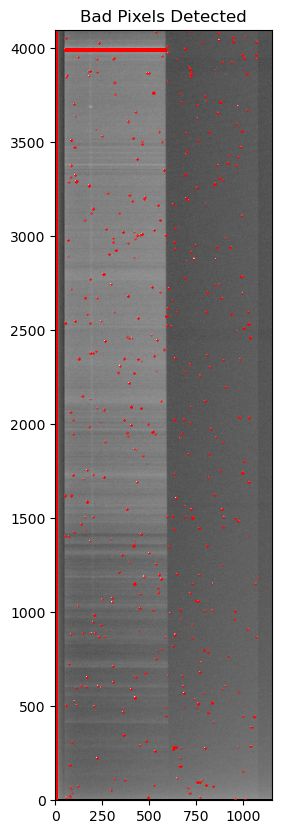

In [29]:
norm = simple_norm(data_107, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(data_107, origin = 'lower', cmap = "grey", norm = norm)
plt.title("Bad Pixels Detected")
y, x = np.where(above_10_std)
plt.scatter(x, y, color='red', s=0.1)
plt.show()

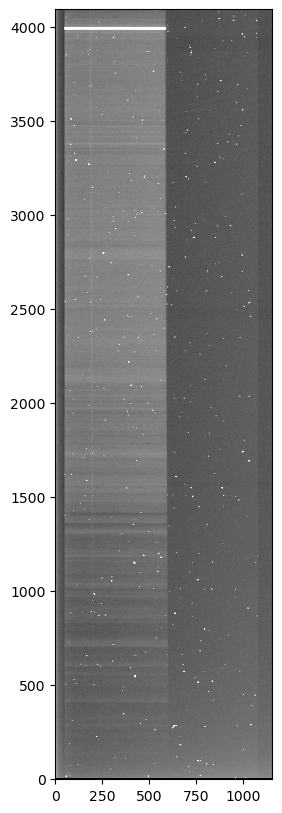

In [30]:
norm = simple_norm(data_107, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(data_107, origin = 'lower', cmap = "grey", norm = norm)
plt.show()

In [31]:
# based on the comparison of both images above, I seem to have successfully marked the bad pixels.
# We will stick with using 10*data_107_std as our range. So, we want pixels that are within
# this value. So anything that is below data_107_median + 10*data_107_std is considered a good pixel
#
#
# I first tried to use only file 107 information but I was still getting cosmic rays.
# So I looped through each and getting their own data for the mask before subtracting bias.

In [32]:
# I believe this code is wrong. This filters ALL bad pixels out.
# It takes away pixels affected by cosmic rays AND bad/dead pixels.
# I only want to exclude the pixels affected by cosmic rays.


minus_bad_pixels_nd_bias = []

for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure == 0:
        hdul.close()
        continue
        
    print(F"Checking file: ", fname)

    data = hdul[2].data

    data_median = np.median(data)
    data_median_mask = (data_median - 50 <= data) & (data <= 50 + data_median)
    data_median_range = data[data_median_mask]
    data_median_std = np.std(data_median_range)
    bad_pixel_range = (data >= data_median + data_median_std*10)


    
    print(F"total number of bad pixels: ", np.sum(bad_pixel_range))
    print("")
    
    clean_data = np.copy(data)
    clean_data[bad_pixel_range] = data_median
    minus_bad_pixels_nd_bias.append(clean_data - median_bias_image)
    hdul.close()
    
print(F"minus_bad_pixels_nd_bias dimension: ", np.shape(minus_bad_pixels_nd_bias))

sum_data_clean = (np.sum(minus_bad_pixels_nd_bias, axis = 0))
print(F"sum_data dimension: ", np.shape(sum_data_clean))

avg_per_hour_all = (np.mean(minus_bad_pixels_nd_bias, axis = 0)/1200)*3600
print(F"avg_per_hour dimension: ", np.shape(avg_per_hour_all))



Checking file:  Part_1/b211011_0107.fits.gz
total number of bad pixels:  13138

Checking file:  Part_1/b211011_0108.fits.gz
total number of bad pixels:  12857

Checking file:  Part_1/b211011_0109.fits.gz
total number of bad pixels:  13848

minus_bad_pixels_nd_bias dimension:  (3, 4096, 1155)
sum_data dimension:  (4096, 1155)
avg_per_hour dimension:  (4096, 1155)


In [33]:
# We can see that the right files were checked, the cube and the summed data were done correctly

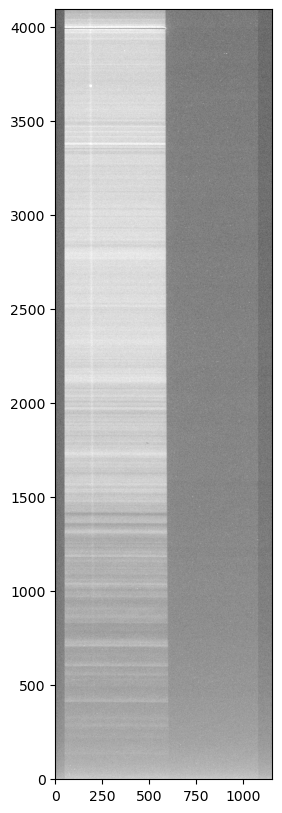

In [34]:
norm = simple_norm(sum_data_clean, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(sum_data_clean, origin = 'lower', cmap = "grey", norm = norm)
plt.show()
# The image of the clean data minus bias summed

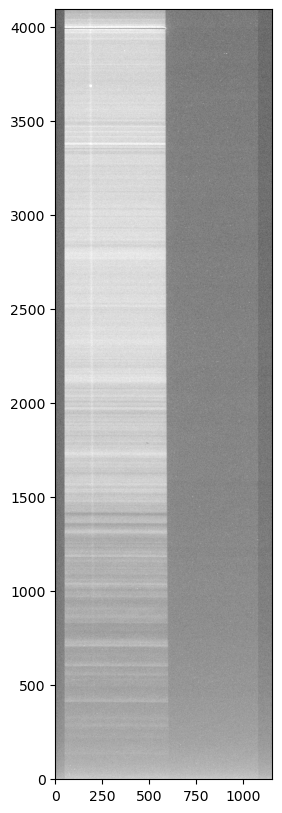

In [35]:
norm = simple_norm(avg_per_hour_all, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(avg_per_hour_all, origin = 'lower', cmap = "grey", norm = norm)
plt.show()
# The image of the clean data minus bias averag/hour

In [36]:
#
#
#
#
#
#
#
#
#
#
# Bottom is the finished/Correct code put together

Checking file:  Part_1/b211011_0102.fits.gz
Checking file:  Part_1/b211011_0103.fits.gz
Checking file:  Part_1/b211011_0104.fits.gz
Checking file:  Part_1/b211011_0105.fits.gz
Checking file:  Part_1/b211011_0106.fits.gz
bias dimension:  (5, 4096, 1155)
median_bias_image dimension =  (4096, 1155)
Displaying master bias image...



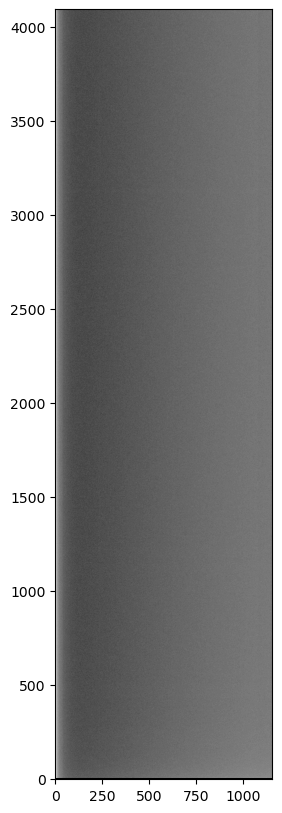

In [91]:
# Creating master bias

files = sorted(glob.glob("Part_1/b211011_01*.fits.gz"))

chip_bias = []
for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure != 0:
        hdul.close()
        continue

    
    data = hdul[2].data

    print(F"Checking file: ", fname)

    chip_bias.append(data)
    hdul.close()
print(F"bias dimension: ", np.shape(chip_bias))

median_bias_image = (np.median(chip_bias, axis = 0))

print(F"median_bias_image dimension = ", np.shape(median_bias_image))
print("Displaying master bias image...")
print("")

norm = simple_norm(median_bias_image, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(median_bias_image, origin = 'lower', cmap = "grey", norm = norm)
plt.show()


# Visual of the master bias

In [92]:
# This portion gathers the information for the constant bad pixels accross all frames.

files = sorted(glob.glob("Part_1/b211011_01*.fits.gz"))
boolian_range = []

for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure == 0:
        hdul.close()
        continue
    data = hdul[0].data

        
    print(F"Checking file: ", fname)

    data = hdul[2].data

    print(F"checking dimension: ", np.shape(data))
    

    data_median = np.median(data)
    data_median_mask = (data_median - 50 <= data) & (data <= 50 + data_median)
    data_median_std = np.std(data[data_median_mask])

    bad_pixel_range = (data >= data_median + data_median_std*10)
    print(F"total bad pixels: ", np.sum(bad_pixel_range))
    print("")

    boolian_range.append(bad_pixel_range)
hdul.close()

const_bad_pix = np.logical_and.reduce(boolian_range)

print(F"Number of bad/dead pixels: ", np.sum(const_bad_pix))
print(F"dimension of const_bad_pix: ", np.shape(const_bad_pix))

Checking file:  Part_1/b211011_0107.fits.gz
checking dimension:  (4096, 1155)
total bad pixels:  13138

Checking file:  Part_1/b211011_0108.fits.gz
checking dimension:  (4096, 1155)
total bad pixels:  12857

Checking file:  Part_1/b211011_0109.fits.gz
checking dimension:  (4096, 1155)
total bad pixels:  13848

Number of bad/dead pixels:  10432
dimension of const_bad_pix:  (4096, 1155)


Checking file:  Part_1/b211011_0107.fits.gz
checking dimension:  (4096, 1155)
Total number of bad pixels in frame:  13138
Total pixels affected by cosmic rays:  2706

Checking file:  Part_1/b211011_0108.fits.gz
checking dimension:  (4096, 1155)
Total number of bad pixels in frame:  12857
Total pixels affected by cosmic rays:  2425

Checking file:  Part_1/b211011_0109.fits.gz
checking dimension:  (4096, 1155)
Total number of bad pixels in frame:  13848
Total pixels affected by cosmic rays:  3416

The total number of bad/dead pixels accross all frames:  10432

data_minus_rays_nd_bias dimension:  (3, 4096, 1155)
avg_per_hour_rays dimension:  (4096, 1155)
Displaying image of final result without cosmic rays...


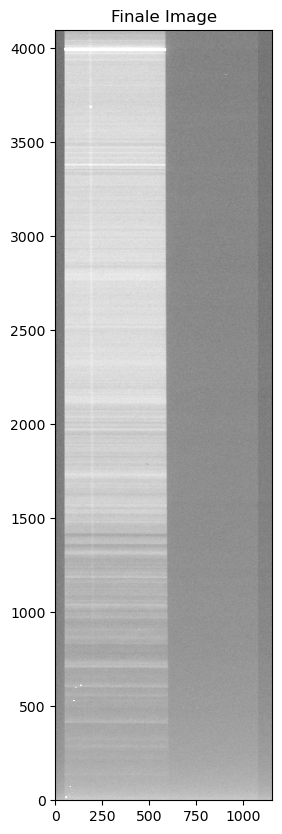

In [93]:
# Here, I use the above information in order to get the image without the cosmic rays only
# I ONLY take out the cosmic rays

exptime = 1200
data_minus_rays_nd_bias = []
cosmic_ray_mask_library = {}
i = 1
std_multipier = 10

for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure == 0:
        hdul.close()
        continue
        
    print(F"Checking file: ", fname)

    data = hdul[2].data

    print(F"checking dimension: ", np.shape(data))


    data_median = np.median(data)
    data_median_mask = (data_median - 50 <= data) & (data <= 50 + data_median)
    data_median_range = data[data_median_mask]
    data_median_std = np.std(data_median_range)
    
    bad_pixel_range = (data >= data_median + data_median_std * std_multipier)
    print(F"Total number of bad pixels in frame: ", np.sum(bad_pixel_range))

    cosmic_ray_mask = np.logical_and(bad_pixel_range, ~const_bad_pix)

    print(F"Total pixels affected by cosmic rays: ", np.sum(cosmic_ray_mask))
    print("")

    cosmic_ray_mask_library[i] = cosmic_ray_mask

    i = i + 1

    
    cosmic_ray_mask = binary_dilation(cosmic_ray_mask, iterations = 2)

    
    data_minus_rays = np.copy(data)
    data_minus_rays[cosmic_ray_mask] = data_median
    data_minus_rays_nd_bias.append(data_minus_rays - median_bias_image)

    hdul.close()
print(F"The total number of bad/dead pixels accross all frames: ", np.sum(const_bad_pix))
print("")

print(F"data_minus_rays_nd_bias dimension: ", np.shape(data_minus_rays_nd_bias))

avg_per_hour_rays = (np.mean(data_minus_rays_nd_bias, axis = 0)/exptime)*3600
print(F"avg_per_hour_rays dimension: ", np.shape(avg_per_hour_rays))

print("Displaying image of final result without cosmic rays...")

norm = simple_norm(avg_per_hour_rays, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(avg_per_hour_rays, origin = 'lower', cmap = "grey", norm = norm)
plt.title("Finale Image")
plt.show()

# Stack of images with all cosmic rays subtracted

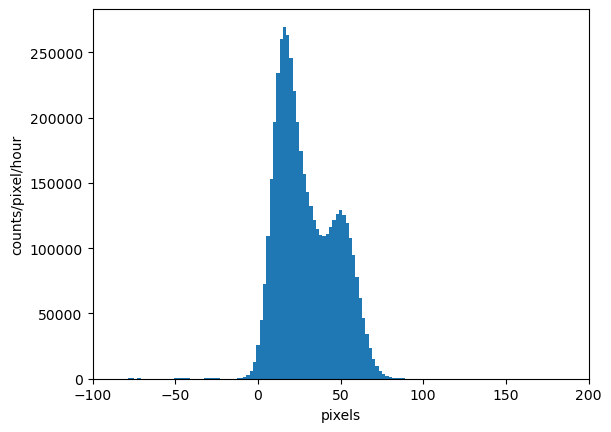

In [40]:
plt.hist(avg_per_hour_rays.flatten(), bins = 100000)
plt.xlim(-100, 200)
plt.xlabel("pixels")
plt.ylabel("counts/pixel/hour")
plt.show()

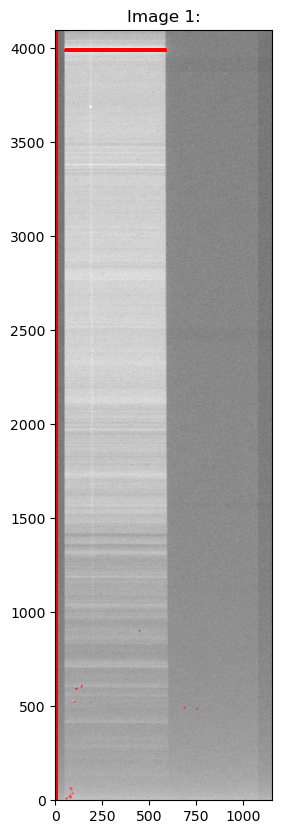

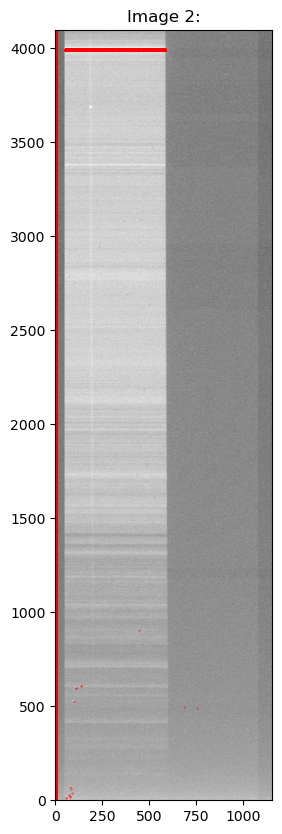

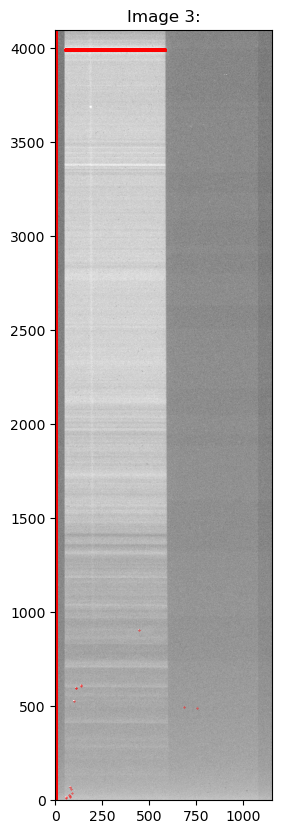

In [94]:
# I notice that in the stacked image above, there are spots that havent gone away. Either my code
# did not detect all cosmic rays or these are the same across all images.
# Will display all images with comsic rays subtracted but before stacking.
for ind in range(0,3):

    norm = simple_norm(data_minus_rays_nd_bias[ind], 'sqrt', percent=99.5)
    plt.figure(figsize=(10, 10))
    
    y, x = np.where(const_bad_pix)
    plt.scatter(x, y, color='red', s=0.1)

    
    plt.imshow(data_minus_rays_nd_bias[ind], origin = 'lower', cmap = "grey", norm = norm)
    plt.title(F"Image {ind + 1}:")
    plt.show()


In [42]:
# As we can see from above, those spots are found accross all frames. these cannot be cosmic rays!

In [43]:
#
#
#
#
# Cosmic-Ray Rejection for Keck/LRIS Red
#
#
#
# 

In [5]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.stats import norm
from astropy.visualization import simple_norm
from scipy.ndimage import binary_dilation

In [78]:
files = sorted(glob.glob("Part_2/r211011_001*.fits.gz"))

for fname in files:
    hdul = fits.open(fname)
    print(F"File information for file:")
    print(hdul.info())
    print("")

File information for file:
Filename: Part_2/r211011_00137.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     336   (4234, 4188)   int16 (rescales to uint16)   
  1  Exposure Events    1 TableHDU        17   1R x 2C   [A26, A80]   
None

File information for file:
Filename: Part_2/r211011_00138.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     336   (4234, 4188)   int16 (rescales to uint16)   
  1  Exposure Events    1 TableHDU        17   1R x 2C   [A26, A80]   
None

File information for file:
Filename: Part_2/r211011_00139.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     336   (4234, 4188)   int16 (rescales to uint16)   
  1  Exposure Events    1 TableHDU        17   1R x 2C   [A26, A80]   
None

File information for file:
Filename: Part_2/r211011_00140.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   For

Checking file:  Part_2/r211011_00137.fits.gz
checking dimension:  (4188, 4234)
Checking file:  Part_2/r211011_00138.fits.gz
checking dimension:  (4188, 4234)
Checking file:  Part_2/r211011_00139.fits.gz
checking dimension:  (4188, 4234)
Checking file:  Part_2/r211011_00140.fits.gz
checking dimension:  (4188, 4234)
Checking file:  Part_2/r211011_00141.fits.gz
checking dimension:  (4188, 4234)
bias dimension:  (5, 4188, 4234)
median_bias_image dimension =  (4188, 4234)
Displaying master bias image...



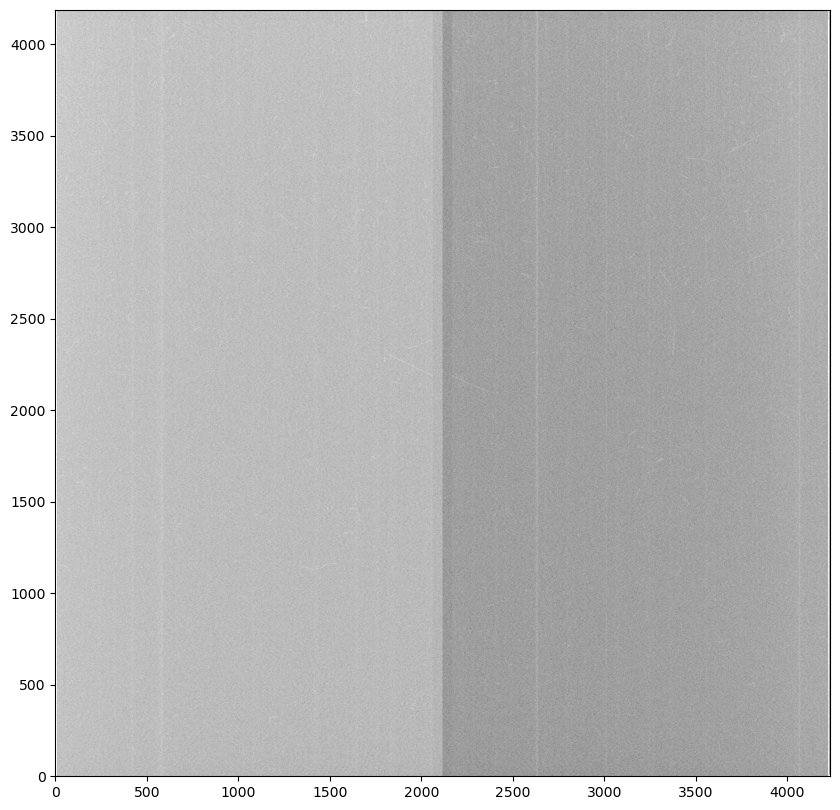

In [8]:
# Creating master bias

files = sorted(glob.glob("Part_2/r211011_001*.fits.gz"))

chip_bias = []
for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure != 0:
        hdul.close()
        continue
    
    data = hdul[0].data

    print(F"Checking file: ", fname)
    
    print(F"checking dimension: ", np.shape(data))

    chip_bias.append(data)
    hdul.close()
print(F"bias dimension: ", np.shape(chip_bias))

median_bias_image = (np.median(chip_bias, axis = 0))

print(F"median_bias_image dimension = ", np.shape(median_bias_image))
print("Displaying master bias image...")
print("")

norm = simple_norm(median_bias_image, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(median_bias_image, origin = 'lower', cmap = "grey", norm = norm)
plt.show()
#
# Visual of the master bias

In [9]:
# This portion gathers the information for the constant bad pixels accross all frames.

files = sorted(glob.glob("Part_2/r211011_001*.fits.gz"))

boolian_range = []
std_multipier = 10


for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure == 0:
        hdul.close()
        continue
        
    print(F"Checking file: ", fname)

    data = hdul[0].data

    print(F"checking dimension: ", np.shape(data))

    data_median = np.median(data)
    data_median_mask = (data_median - 50 <= data) & (data <= 50 + data_median)
    data_median_std = np.std(data[data_median_mask])

    bad_pixel_range = (data >= data_median + data_median_std * std_multipier)
    print(F"total bad pixels: ", np.sum(bad_pixel_range))
    print("")

    boolian_range.append(bad_pixel_range)
hdul.close()

const_bad_pix = np.logical_and.reduce(boolian_range)

print(F"Number of bad/dead pixels: ", np.sum(const_bad_pix))
print(F"dimension of const_bad_pix: ", np.shape(const_bad_pix))

Checking file:  Part_2/r211011_00142.fits.gz
checking dimension:  (4188, 4234)
total bad pixels:  566997

Checking file:  Part_2/r211011_00143.fits.gz
checking dimension:  (4188, 4234)
total bad pixels:  523324

Checking file:  Part_2/r211011_00144.fits.gz
checking dimension:  (4188, 4234)
total bad pixels:  561263

Number of bad/dead pixels:  410607
dimension of const_bad_pix:  (4188, 4234)


Checking file:  Part_2/r211011_00142.fits.gz
checking dimension:  (4188, 4234)
Total number of bad pixels in frame:  247451
Total pixels affected by cosmic rays:  74903

Checking file:  Part_2/r211011_00143.fits.gz
checking dimension:  (4188, 4234)
Total number of bad pixels in frame:  222781
Total pixels affected by cosmic rays:  72978

Checking file:  Part_2/r211011_00144.fits.gz
checking dimension:  (4188, 4234)
Total number of bad pixels in frame:  237220
Total pixels affected by cosmic rays:  70825

The total number of bad/dead pixels accross all frames:  410607

data_minus_rays_nd_bias dimension:  (3, 4188, 4234)
avg_per_hour_rays dimension:  (4188, 4234)
Displaying image of final result without cosmic rays...


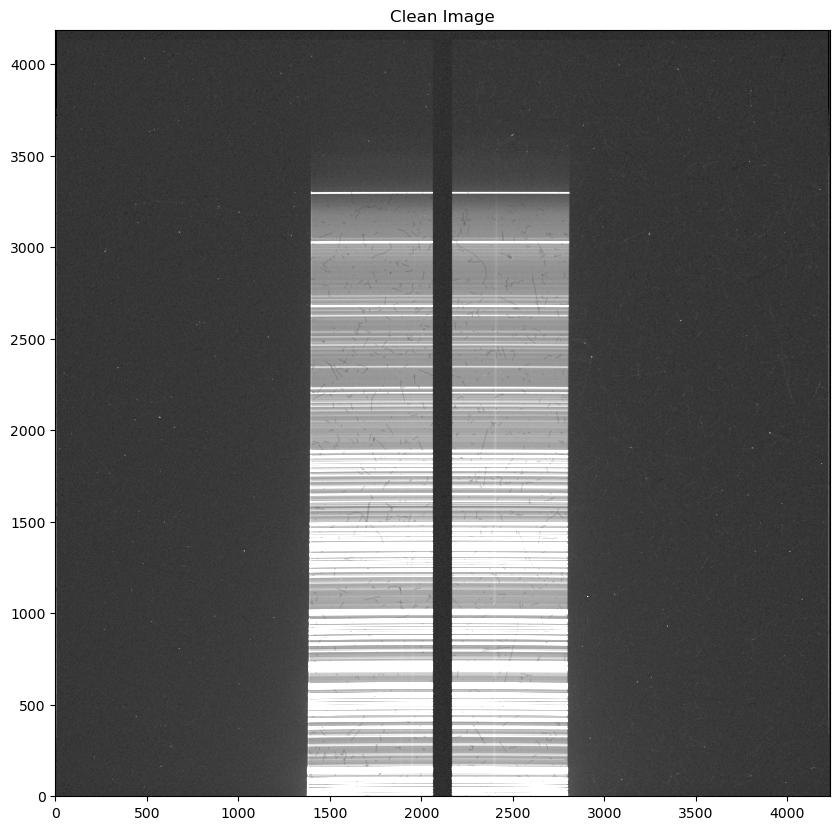

In [10]:
# Here, I use the above information in order to get the image without the cosmic rays only
# I had to add the std_multipier in so that it can better grasp the cosmic rays.
# std_multipier = 10 wasn't working so had to increase the width

files = sorted(glob.glob("Part_2/r211011_001*.fits.gz"))
exptime = 600
data_minus_rays_nd_bias = []
cosmic_ray_mask_library = {}
i = 1
std_multipier = 20

for fname in files:
    hdul = fits.open(fname)
    
    exposure = hdul[0].header['TTIME']
    if exposure == 0:
        hdul.close()
        continue
        
    print(F"Checking file: ", fname)

    data = hdul[0].data

    print(F"checking dimension: ", np.shape(data))


    data_median = np.median(data)
    data_median_mask = (data_median - 50 <= data) & (data <= 50 + data_median)
    data_median_range = data[data_median_mask]
    data_median_std = np.std(data_median_range)
    
    bad_pixel_range = (data >= data_median + data_median_std * std_multipier)
    print(F"Total number of bad pixels in frame: ", np.sum(bad_pixel_range))

    cosmic_ray_mask = np.logical_and(bad_pixel_range, ~const_bad_pix)
    print(F"Total pixels affected by cosmic rays: ", np.sum(cosmic_ray_mask))
    print("")

    cosmic_ray_mask_library[i] = cosmic_ray_mask
    i = i + 1

    cosmic_ray_mask = binary_dilation(cosmic_ray_mask, iterations = 2)

    
    data_minus_rays = np.copy(data)
    data_minus_rays[cosmic_ray_mask] = data_median
    data_minus_rays_nd_bias.append(data_minus_rays - median_bias_image)

    hdul.close()
print(F"The total number of bad/dead pixels accross all frames: ", np.sum(const_bad_pix))
print("")

print(F"data_minus_rays_nd_bias dimension: ", np.shape(data_minus_rays_nd_bias))

avg_per_hour_rays = (np.mean(data_minus_rays_nd_bias, axis = 0)/exptime)*3600
print(F"avg_per_hour_rays dimension: ", np.shape(avg_per_hour_rays))

print("Displaying image of final result without cosmic rays...")

norm = simple_norm(avg_per_hour_rays, 'sqrt', percent= 90)
plt.figure(figsize=(10, 10))
plt.imshow(avg_per_hour_rays, origin = 'lower', cmap = "grey", norm = norm)
plt.title("Clean Image")
plt.show()

# This image has all cosmic rays subtracted

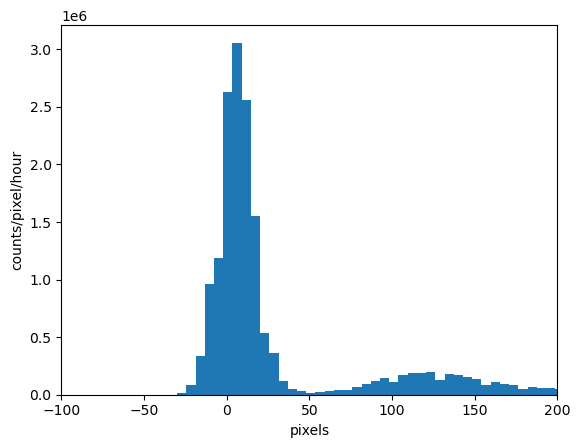

In [24]:
plt.hist(avg_per_hour_rays.flatten(), bins = 5000)
plt.xlim(-100, 200)

plt.xlabel("pixels")
plt.ylabel("counts/pixel/hour")
plt.show()

In [50]:
fits.writeto("best_image.fits", avg_per_hour_rays, overwrite = True)

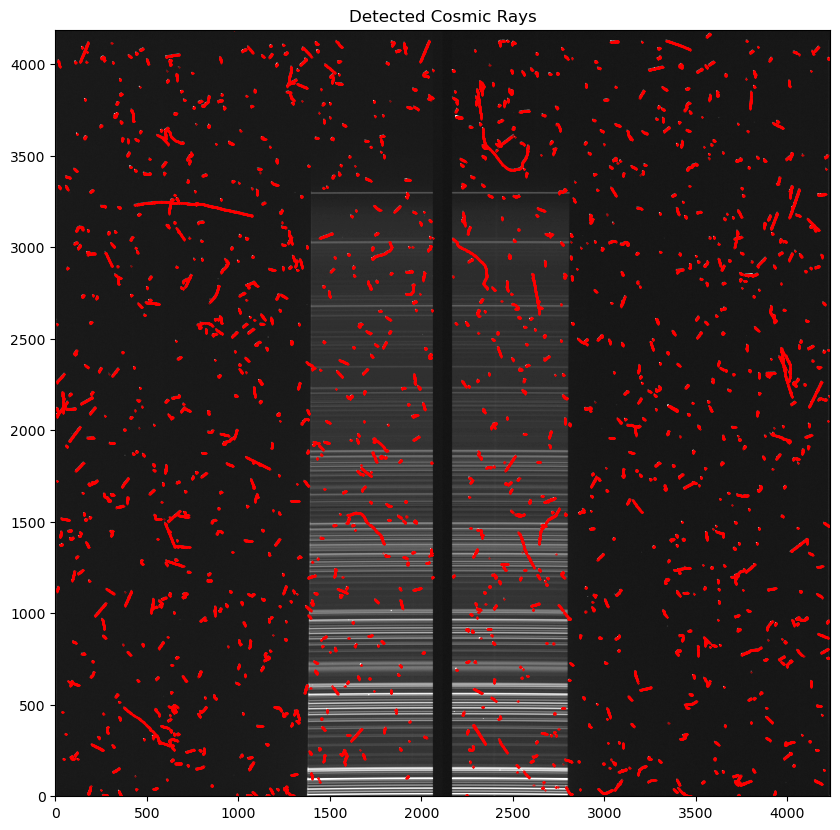

In [51]:
# Overlaying the pixels affected by cosmic rays on a raw image

raw_image =  fits.open("Part_2/r211011_00142.fits.gz")[0].data

norm = simple_norm(raw_image, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow(raw_image, origin = 'lower', cmap = "grey", norm = norm)
plt.title("Detected Cosmic Rays")
y, x = np.where(cosmic_ray_mask_library[1])
plt.scatter(x, y, color='red', s=0.1)
plt.show()

In [52]:
# Above image shows how accurate it was able to detect the cosmic rays

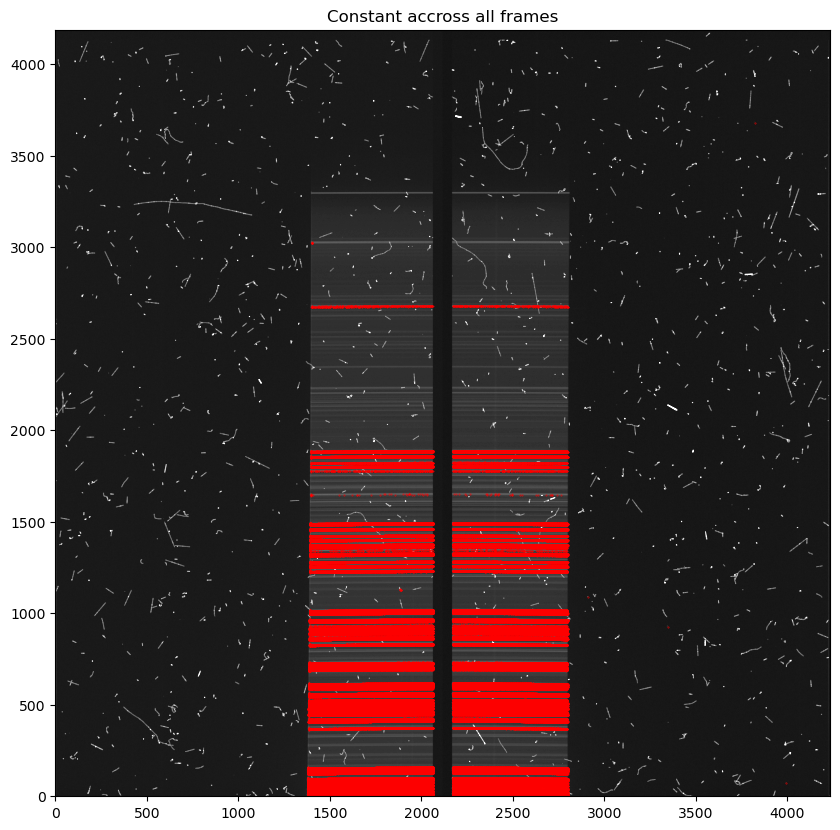

In [53]:
# Overlaying the constant bad pixels on a raw image
raw_image =  fits.open("Part_2/r211011_00142.fits.gz")[0].data

norm = simple_norm(raw_image, 'sqrt', percent=99.5)
plt.figure(figsize=(10, 10))
plt.imshow( raw_image, origin = 'lower', cmap = "grey", norm = norm)
plt.title("Constant accross all frames")
y, x = np.where(const_bad_pix)
plt.scatter(x, y, color='red', s=0.1)
plt.show()

In [54]:
# Above is what it would detect accross all frames

In [55]:
# Below I display each image seperatly before stacking

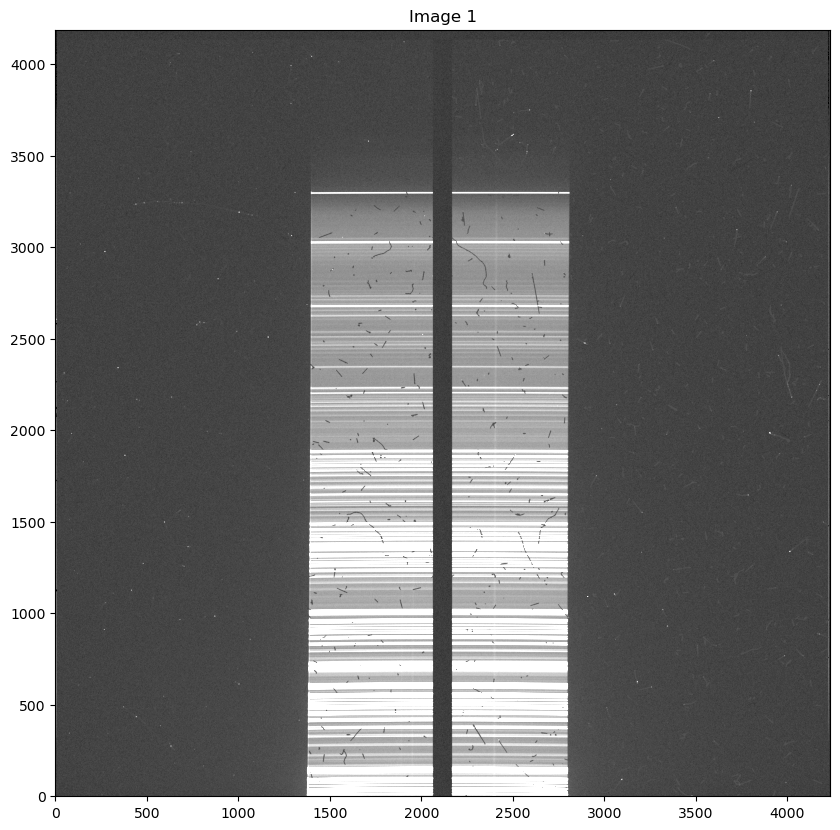

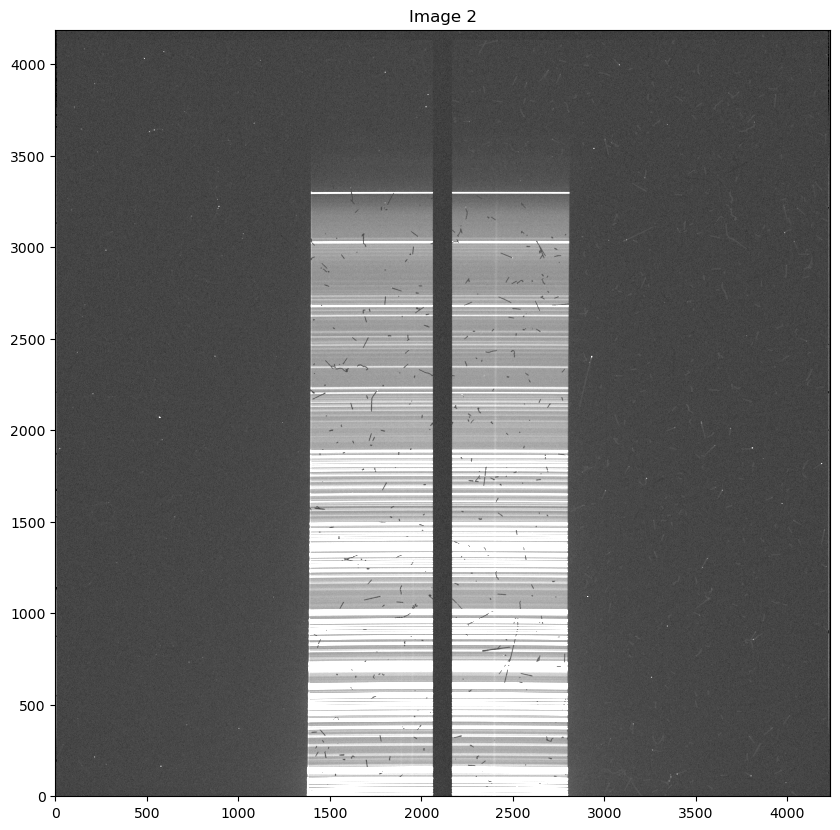

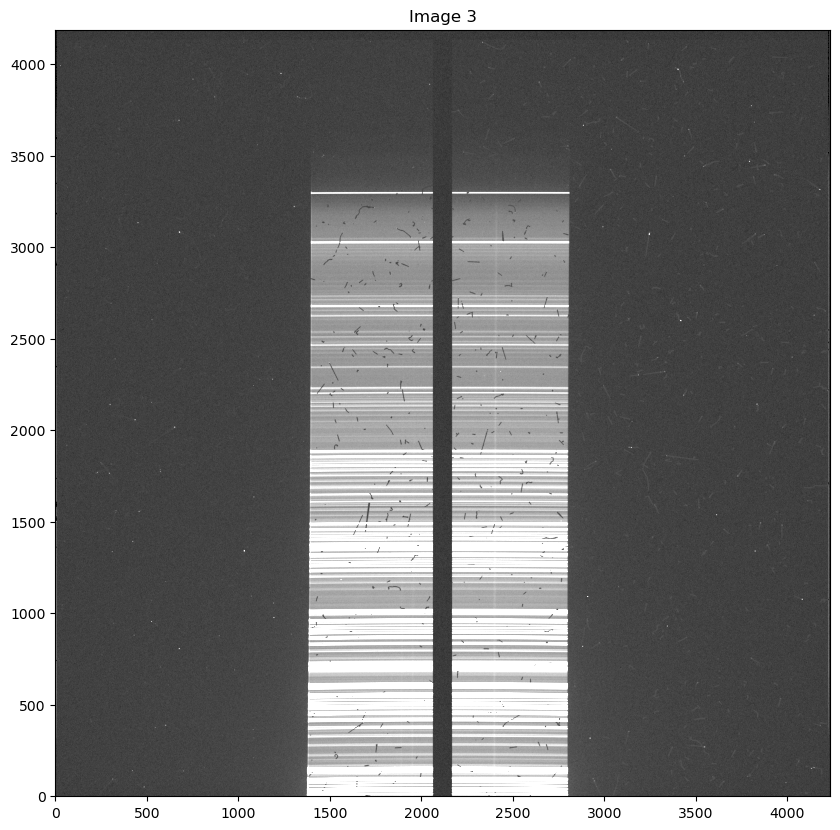

In [56]:
# each image with bias subtracted and cosmic rays filled in
for ind in range(0,3):

    norm = simple_norm(data_minus_rays_nd_bias[ind], 'sqrt', percent= 90)
    plt.figure(figsize=(10, 10))
    plt.imshow(data_minus_rays_nd_bias[ind], origin = 'lower', cmap = "grey", norm = norm)
    plt.title(F"Image {ind + 1}")
    plt.show()


In [57]:
#
#
#
#
# Cosmic-Ray Rejection for Individual Frames
#
#
#
# 

In [58]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.stats import norm
from astropy.visualization import simple_norm
from scipy.ndimage import median_filter, binary_dilation, label

In [59]:
hdul = fits.open("Part_3/r210216_0060.fits.gz")

In [60]:
hdul.info()

Filename: Part_3/r210216_0060.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     720   ()      
  1  VidInp1       1 ImageHDU       359   (1735, 2520)   int16 (rescales to uint16)   
  2  VidInp3       1 ImageHDU       359   (1839, 2520)   int16 (rescales to uint16)   


In [61]:
data = hdul[1].data

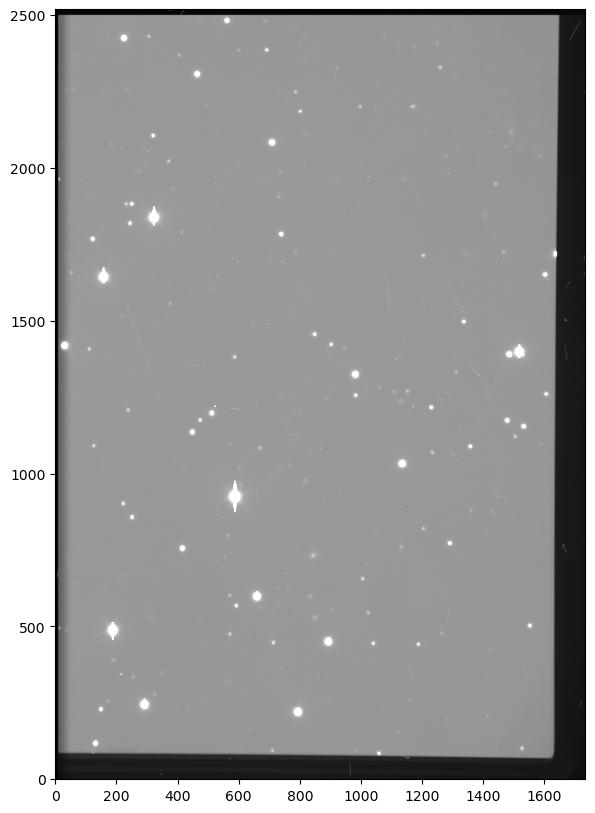

In [62]:
norm = simple_norm(data, 'sqrt', percent=99.5)
plt.figure(figsize = (10,10))
plt.imshow(data, origin = 'lower', cmap = 'grey', norm = norm)
plt.show()

In [63]:
fits.writeto("Part_3/raw_image_ext1", data, overwrite = True)

In [64]:
np.shape(data)

(2520, 1735)

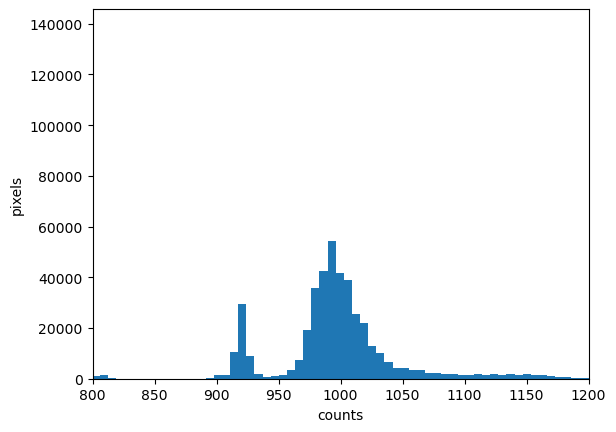

In [65]:
plt.hist(data.flatten(), bins = 10000)
plt.xlim(800,1200)
plt.xlabel("counts")
plt.ylabel("pixels")
plt.show()

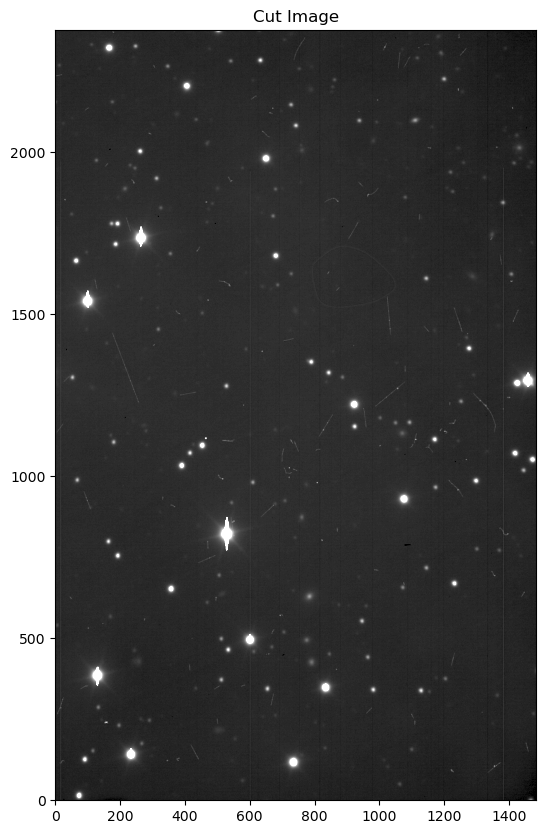

In [66]:
# I will cut the iamge by getting rid of the dark edges

data_cut = data[103:2480, 58:1542]
norm = simple_norm(data_cut, 'sqrt', percent=99.5)
plt.figure(figsize = (10,10))
plt.title("Cut Image")
plt.imshow(data_cut, origin = 'lower', cmap = 'grey', norm = norm)
plt.show()

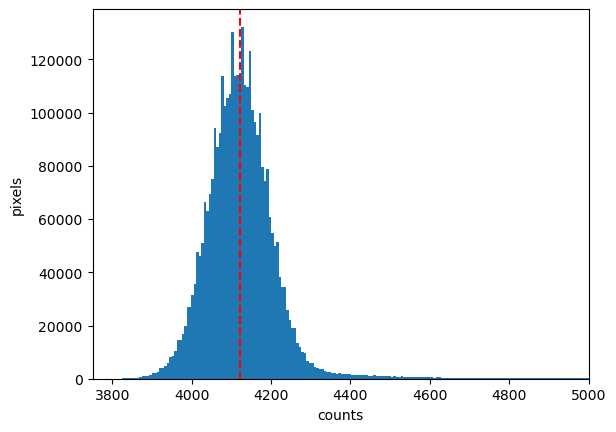

In [67]:
plt.hist(data_cut.flatten(), bins = 10000)
plt.axvline(np.median(data_cut), color = "red", linestyle = "--")

plt.xlim(3750,5000)
plt.xlabel("counts")
plt.ylabel("pixels")
plt.show()

In [68]:
fits.writeto("Part_3/cut", data_cut, overwrite = True)

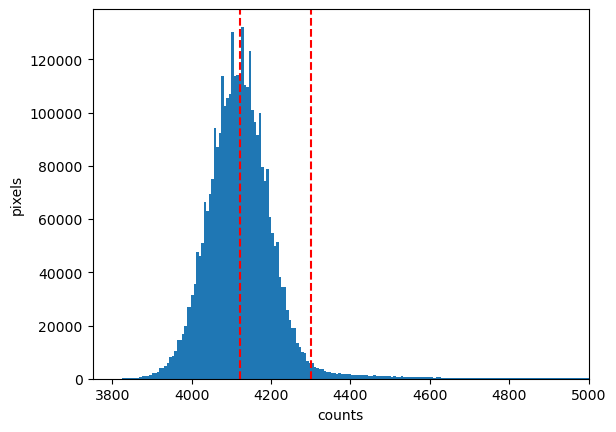

In [69]:
plt.hist(data_cut.flatten(), bins = 10000)
plt.axvline(np.median(data_cut), color = "red", linestyle = "--")
plt.axvline(4300, color = "red", linestyle = "--")

plt.xlim(3750,5000)
plt.xlabel("counts")
plt.ylabel("pixels")
plt.show()

In [70]:
hdul = fits.open("Part_3/r210216_0060.fits.gz")
data = hdul[1].data[103:2480, 58:1542].astype(float)

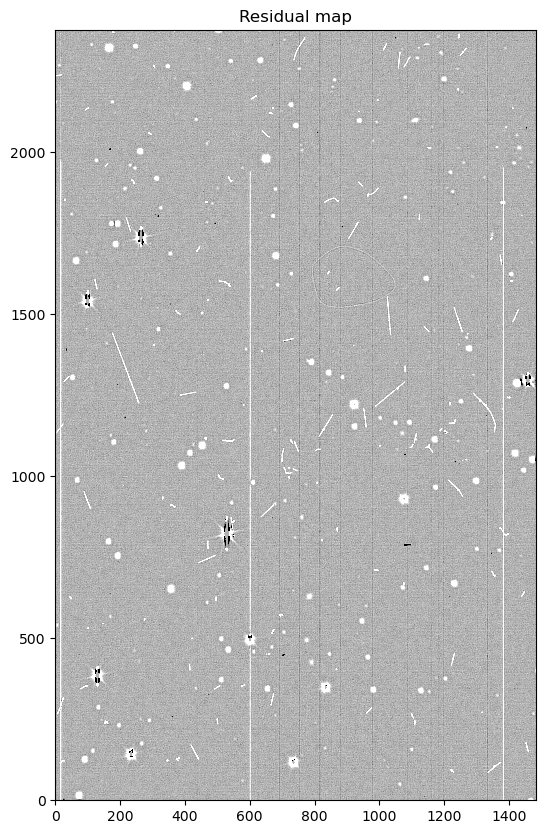

In [71]:
# Getting local median

smooth = median_filter(data, size = 7)
residual = data - smooth

# A look into the residual map

norm = simple_norm(residual, 'sqrt', percent= 90)
plt.figure(figsize=(10, 10))
plt.title("Residual map")
plt.imshow(residual, origin = 'lower', cmap = "grey", norm = norm)
plt.show()

In [72]:
local_noise = median_filter(np.abs(residual), size = 15)

multiplier = 6.0
ray_mask = residual >= (multiplier * local_noise)

In [73]:
labeled, n = label(ray_mask)
sizes = np.bincount(labeled.ravel())
mask_sizes = (sizes >= 3) & (sizes <= 50)
filtered_mask = mask_sizes[labeled]

print(F"Cosmic rays detected: {np.sum(filtered_mask)}")
print(F"Percentage of pixels detected: {( (np.sum(filtered_mask)) / (np.size(data)) ) * 100}")

filtered_mask = binary_dilation(filtered_mask, iterations=2)


Cosmic rays detected: 7772
Percentage of pixels detected: 0.22032800864529456


In [74]:
cleaned = np.copy(data)
cleaned[filtered_mask] = smooth[filtered_mask]

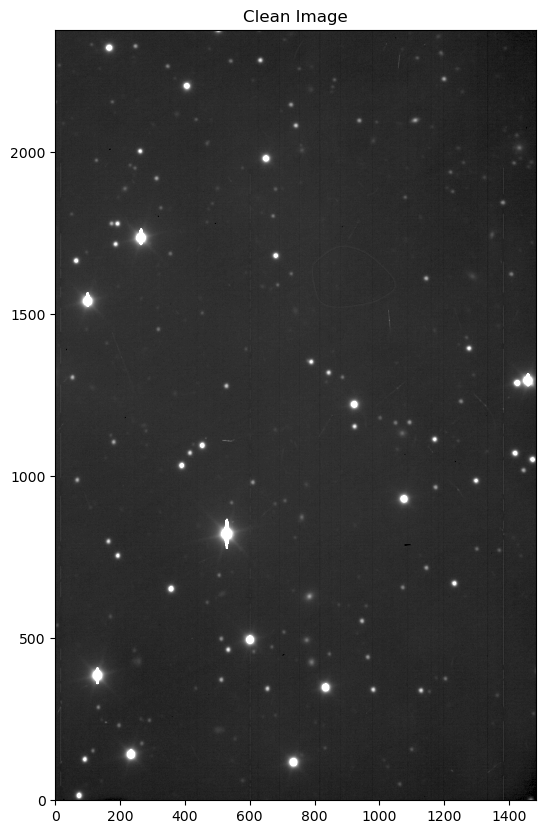

In [75]:
norm = simple_norm(cleaned, 'sqrt', percent=99.5)
plt.figure(figsize = (10,10))
plt.title("Clean Image")
plt.imshow(cleaned, origin = 'lower', cmap = 'grey', norm = norm)
plt.show()

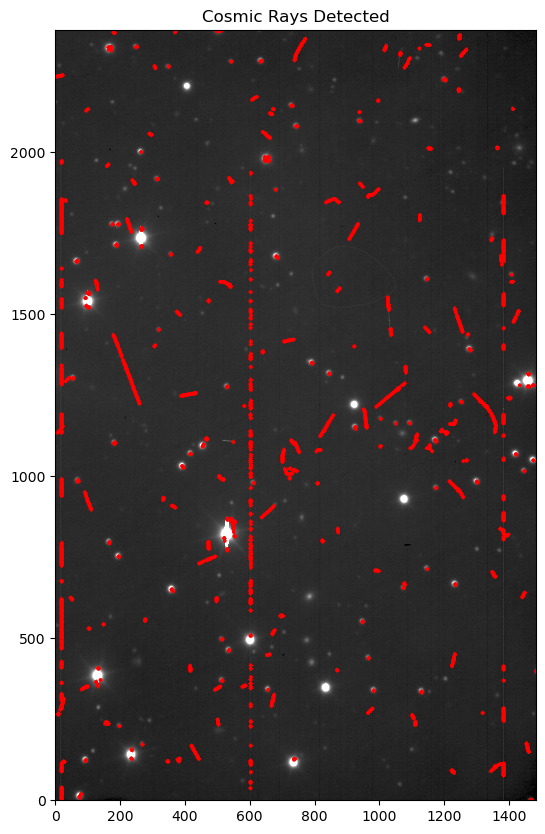

In [76]:
norm = simple_norm(data, 'sqrt', percent=99.5)
plt.figure(figsize = (10,10))
plt.imshow(data, origin = 'lower', cmap = 'grey', norm = norm)
plt.title("Cosmic Rays Detected")
y, x = np.where(filtered_mask)
plt.scatter(x, y, color='red', s=0.1)
plt.show()